<a href="https://colab.research.google.com/github/Takayoshi-code/nanoGPT-class/blob/master/nanoGPT_Aozora_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP1 nanoGPT環境をGitHubからダウンロードしてGoogle Colab上に展開します。

In [1]:
# ===== 安全版 =====

import os

print("===== Step 0: /content に移動 =====")
%cd /content

print("===== Step 1: クリーン =====")
!rm -rf nanoGPT
!rm -f master.zip

print("===== Step 2: ライブラリ =====")
!pip install -q sentencepiece datasets tqdm

print("===== Step 3: nanoGPT取得 =====")

!wget -q https://github.com/Takayoshi-code/nanoGPT-class/archive/refs/heads/master.zip
!unzip -q master.zip
!mv nanoGPT-class-master nanoGPT

print("===== Step 4: 移動 =====")
%cd /content/nanoGPT

print("===== Step 5: 確認 =====")
!ls

===== Step 0: /content に移動 =====
/content
===== Step 1: クリーン =====
===== Step 2: ライブラリ =====
===== Step 3: nanoGPT取得 =====
===== Step 4: 移動 =====
/content/nanoGPT
===== Step 5: 確認 =====
assets		 LICENSE		    scaling_laws.ipynb
bench.py	 model.py		    train.py
config		 nanoGPT_Aozora_tiny.ipynb  transformer_sizing.ipynb
configurator.py  README.md
data		 sample.py


##　　参考　青空文庫収録作家一覧

In [ ]:
import io
import zipfile
import requests
import pandas as pd

URL = "https://www.aozora.gr.jp/index_pages/list_person_all_extended_utf8.zip"

print("青空文庫のデータを取得中...")

r = requests.get(URL, timeout=60)
r.raise_for_status()

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    csv_name = [x for x in z.namelist() if x.endswith(".csv")][0]
    with z.open(csv_name) as f:
        df = pd.read_csv(f, low_memory=False)

df["作家名"] = (
    df["姓"].fillna("").astype(str).str.strip()
    + " "
    + df["名"].fillna("").astype(str).str.strip()
).str.strip()

authors = (
    df.groupby(["人物ID", "作家名"], as_index=False)
      .agg(公開作品数=("作品ID", "nunique"))
      .sort_values(["作家名", "人物ID"])
      .reset_index(drop=True)
)

print(f"\n収録作家数: {len(authors):,}人")
print("=" * 70)

for i, row in authors.iterrows():
    print(
        f"{i:4d}: {row['作家名']:<20} "
        f"人物ID={row['人物ID']:<6} "
        f"作品数={row['公開作品数']}"
    )

青空文庫のデータを取得中...

収録作家数: 1,335人
   0: Morishous T.H.E creative 人物ID=2255   作品数=2
   1: The Creative CAT     人物ID=1834   作品数=31
   2: hiro                 人物ID=1280   作品数=2
   3: sogo                 人物ID=913    作品数=3
   4: かぐつち みどり             人物ID=968    作品数=1
   5: ささき ふさ               人物ID=911    作品数=1
   6: とだ けん                人物ID=970    作品数=1
   7: アイプ・ロシディ             人物ID=2313   作品数=1
   8: アインシュタイン アルベルト       人物ID=1428   作品数=1
   9: アウンチェイン              人物ID=2396   作品数=1
  10: アポリネール ギヨーム          人物ID=2135   作品数=1
  11: アミーチス エドモンド・デ        人物ID=1048   作品数=1
  12: アラルコン ペドロ・アントニオ      人物ID=1716   作品数=1
  13: アリ サバハッティン           人物ID=2315   作品数=1
  14: アルチバシェッフ ミハイル・ペトローヴィチ 人物ID=366    作品数=3
  15: アルテンベルク ペーター         人物ID=1190   作品数=1
  16: アレニウス スヴァンテ          人物ID=226    作品数=1
  17: アレン ジェームズ            人物ID=1842   作品数=1
  18: アレン リリー・Ｌ            人物ID=1843   作品数=1
  19: アンデルセン ハンス・クリスチャン    人物ID=19     作品数=51
  20: アンドレーエフ レオニード・ニコラーエヴィチ 人物ID=907    作品数=2
  21: アークム フレデリ

## STEP2 作家、作品を選んでクリーニングして入力コーパスを作成します。


In [3]:
import io
import os
import re
import zipfile
import requests
import pandas as pd
from tqdm import tqdm
from bs4 import BeautifulSoup
from urllib.parse import urljoin

CSV_ZIP_URL = "https://www.aozora.gr.jp/index_pages/list_person_all_extended_utf8.zip"
BASE_DIR = "/content/nanoGPT/novel_selected"
RAW_OUTPUT = os.path.join(BASE_DIR, "selected_works.txt")
CLEAN_OUTPUT = os.path.join(BASE_DIR, "selected_works_clean.txt")
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; AozoraDownloader/1.0)"}

def normalize_name(s):
    if pd.isna(s):
        return ""
    return str(s).replace(" ", "").replace("　", "").strip()

def decode_aozora_text(raw):
    for enc in ["shift_jis", "cp932", "utf-8-sig", "utf-8"]:
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            pass
    raise RuntimeError("文字コードを判定できませんでした。")

def clean_text(text):
    lines = text.split("\n")
    result = []
    started = False

    for line in lines:
        raw = line
        line = line.strip()

        if line.startswith("<|title|>"):
            continue
        if line.startswith("<|author|>"):
            continue

        if not started:
            if raw.startswith("　") and len(line) > 10 and "。" in line:
                started = True
            else:
                continue

        if (
            line.startswith("底本")
            or line.startswith("初出")
            or line.startswith("入力")
            or line.startswith("校正")
            or line.startswith("青空文庫")
            or line.startswith("作成ファイル")
            or "青空文庫作成ファイル" in line
        ):
            break

        if (
            "記号について" in line
            or "JIS" in line
            or "入力に使用" in line
            or "校正に使用" in line
        ):
            continue

        if re.fullmatch(r"[一二三四五六七八九十百千万]+", line):
            continue

        if re.fullmatch(r"[ⅠⅡⅢⅣⅤⅥⅦⅧⅨⅩ]+", line):
            continue

        if line in {"上", "中", "下", "前編", "後編", "序", "跋", "附録", "解説"}:
            continue

        line = re.sub(r"｜", "", line)
        line = re.sub(r"《.*?》", "", line)
        line = re.sub(r"［＃.*?］", "", line)
        line = re.sub(r"〔.*?〕", "", line)
        line = re.sub(r"（注.*?）", "", line)
        line = re.sub(r"（[\d０-９]+）", "", line)

        line = line.replace("／＼", "")
        line = line.replace("※", "")
        line = line.replace("＊", "")

        if re.fullmatch(r"[0-9０-９A-Za-z]+", line):
            continue

        if len(line) < 2:
            continue

        result.append(line)

    text = "\n".join(result)
    text = re.sub(r"\n{3,}", "\n\n", text)

    if text.count("。") < 10:
        return ""

    if len(text) < 1000:
        return ""

    return text.strip()

def download_work(card_url):
    r = requests.get(card_url, headers=HEADERS, timeout=60)
    r.raise_for_status()
    r.encoding = r.apparent_encoding
    soup = BeautifulSoup(r.text, "html.parser")

    zip_candidates = []

    for a in soup.find_all("a", href=True):
        href = a["href"]
        if href.lower().split("?")[0].endswith(".zip"):
            url = urljoin(card_url, href)
            label = a.get_text(" ", strip=True)
            priority = 0 if "テキスト" in label else 1
            zip_candidates.append((priority, url))

    if not zip_candidates:
        return None

    zip_candidates.sort(key=lambda x: x[0])

    for _, zip_url in zip_candidates:
        try:
            r = requests.get(zip_url, headers=HEADERS, timeout=60)
            r.raise_for_status()

            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                txt_files = [name for name in z.namelist() if name.lower().endswith(".txt")]

                if not txt_files:
                    continue

                raw = z.read(txt_files[0])
                return decode_aozora_text(raw)

        except Exception:
            continue

    return None

def main():
    os.makedirs(BASE_DIR, exist_ok=True)

    print("青空文庫の作品一覧を取得しています...")

    r = requests.get(CSV_ZIP_URL, headers=HEADERS, timeout=60)
    r.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        csv_files = [name for name in z.namelist() if name.lower().endswith(".csv")]
        if not csv_files:
            raise RuntimeError("CSVが見つかりません。")
        with z.open(csv_files[0]) as f:
            df = pd.read_csv(f, low_memory=False)

    print(f"登録データ数: {len(df):,}")

    df["作家名"] = (
        df["姓"].fillna("").astype(str).str.strip()
        + " "
        + df["名"].fillna("").astype(str).str.strip()
    ).str.strip()

    df["作家名検索用"] = df["作家名"].apply(normalize_name)

    keyword = input("作家名を入力してください: ").strip()
    keyword_normalized = normalize_name(keyword)

    mask = df["作家名検索用"].str.contains(
        keyword_normalized,
        na=False,
        regex=False
    )

    authors = (
        df.loc[mask, ["人物ID", "作家名"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    if len(authors) == 0:
        raise ValueError(f"「{keyword}」に該当する作家が見つかりません。")

    print("\n=== 作家候補 ===")

    for i, row in authors.iterrows():
        print(f"{i:3d}: {row['作家名']} (人物ID={row['人物ID']})")

    if len(authors) == 1:
        n = 0
        print("候補が1人なので自動選択します。")
    else:
        while True:
            try:
                n = int(input("左端の選択番号を入力してください: "))
                if 0 <= n < len(authors):
                    break
            except ValueError:
                pass
            print(f"0～{len(authors)-1}を入力してください。")

    author_id = authors.iloc[n]["人物ID"]
    author_name = authors.iloc[n]["作家名"]

    print(f"\n選択した作家: {author_name} (人物ID={author_id})")

    columns = ["作品ID", "作品名", "図書カードURL"]

    if "副題" in df.columns:
        columns.insert(2, "副題")

    works = (
        df.loc[df["人物ID"] == author_id, columns]
        .drop_duplicates(subset=["作品ID"])
        .reset_index(drop=True)
    )

    print(f"\n=== {author_name} の作品一覧（{len(works)}作品）===")

    for i, row in works.iterrows():
        title = str(row["作品名"])

        if "副題" in works.columns and pd.notna(row["副題"]):
            subtitle = str(row["副題"]).strip()
            if subtitle:
                title += " ― " + subtitle

        print(f"{i:3d}: {title} (作品ID={row['作品ID']})")

    print("\n複数選択できます。")
    print("例: 0,3,5,8")
    print("全作品: all")

    selection = input("作品番号を入力してください: ").strip()

    if selection.lower() == "all":
        selected_indices = list(range(len(works)))
    else:
        try:
            selected_indices = [int(x.strip()) for x in selection.split(",")]
        except ValueError:
            raise ValueError("作品番号は 0,3,5 の形式で入力してください。")

    selected_indices = list(dict.fromkeys(selected_indices))

    for i in selected_indices:
        if i < 0 or i >= len(works):
            raise ValueError(f"作品番号 {i} は範囲外です。")

    print(f"\n{len(selected_indices)}作品をダウンロードします。")

    downloaded = []

    for number, i in enumerate(selected_indices, 1):
        work = works.iloc[i]
        title = str(work["作品名"])
        card_url = str(work["図書カードURL"])

        print(f"[{number}/{len(selected_indices)}] {title}")

        try:
            text = download_work(card_url)
        except Exception as e:
            print(f"  → ERROR: {e}")
            continue

        if text is None:
            print("  → TXTを取得できませんでした。")
            continue

        downloaded.append({
            "title": title,
            "text": text
        })

        print(f"  → OK {len(text):,} chars")

    if not downloaded:
        raise RuntimeError("作品を1件も取得できませんでした。")

    print(f"\nRAWファイルを作成: {RAW_OUTPUT}")

    with open(RAW_OUTPUT, "w", encoding="utf-8") as out:
        for item in downloaded:
            out.write(f"<|title|>{item['title']}\n")
            out.write(f"<|author|>{author_name}\n")
            out.write(item["text"])
            out.write("\n\n<|endoftext|>\n\n")

    original_size = os.path.getsize(RAW_OUTPUT)

    print("\nクリーニングを開始します...")

    total = len(downloaded)
    kept = 0
    total_chars = 0

    with open(CLEAN_OUTPUT, "w", encoding="utf-8") as out:
        for item in tqdm(downloaded):
            cleaned = clean_text(item["text"])

            if cleaned:
                chars = len(cleaned)
                kept += 1
                total_chars += chars

                print(f"Work {kept:2d}: {item['title']} : {chars:,} chars")

                out.write(cleaned)
                out.write("\n\n<|endoftext|>\n\n")
            else:
                print(f"REMOVED: {item['title']}")

    cleaned_size = os.path.getsize(CLEAN_OUTPUT)

    print()
    print("====================================")
    print(f"Author           : {author_name}")
    print(f"Selected works   : {len(selected_indices)}")
    print(f"Downloaded works : {total}")
    print(f"Kept works       : {kept}")
    print(f"Removed works    : {total-kept}")
    print("------------------------------------")
    print(f"Total chars      : {total_chars:,}")
    print(f"Original size    : {original_size/1024:.1f} KB")
    print(f"Cleaned size     : {cleaned_size/1024:.1f} KB")

    if original_size > 0:
        print(f"Reduction        : {100*(1-cleaned_size/original_size):.1f}%")

    print("------------------------------------")
    print(f"RAW output       : {RAW_OUTPUT}")
    print(f"Clean output     : {CLEAN_OUTPUT}")
    print("====================================")

if __name__ == "__main__":
    main()

青空文庫の作品一覧を取得しています...
登録データ数: 19,502
作家名を入力してください: 太宰治

=== 作家候補 ===
  0: 太宰 治 (人物ID=35)
候補が1人なので自動選択します。

選択した作家: 太宰 治 (人物ID=35)

=== 太宰 治 の作品一覧（274作品）===
  0: ア、秋 (作品ID=236)
  1: I can speak (作品ID=1572)
  2: 愛と美について (作品ID=1578)
  3: 青森 (作品ID=46597)
  4: 青森 (作品ID=4357)
  5: 朝 (作品ID=1562)
  6: あさましきもの (作品ID=240)
  7: 新しい形の個人主義 (作品ID=42360)
  8: 兄たち (作品ID=239)
  9: 雨の玉川心中 ― 02 遺書 (作品ID=58054)
 10: 或る忠告 (作品ID=42356)
 11: 老ハイデルベルヒ (作品ID=238)
 12: 『老ハイデルベルヒ』序 (作品ID=54179)
 13: 一日の労苦 (作品ID=1592)
 14: 一問一答 (作品ID=1598)
 15: 一灯 (作品ID=273)
 16: 一歩前進二歩退却 (作品ID=1593)
 17: 田舎者 (作品ID=42362)
 18: 『井伏鱒二選集』後記 (作品ID=42359)
 19: 陰火 (作品ID=272)
 20: ヴィヨンの妻 (作品ID=2253)
 21: 嘘 (作品ID=2254)
 22: 右大臣実朝 (作品ID=2255)
 23: 鬱屈禍 (作品ID=42354)
 24: 姥捨 (作品ID=2256)
 25: 『姥捨』あとがき (作品ID=54169)
 26: 海 (作品ID=42363)
 27: 炎天汗談 (作品ID=43071)
 28: 黄金風景 (作品ID=2257)
 29: 黄村先生言行録 (作品ID=287)
 30: 桜桃 (作品ID=308)
 31: 緒方氏を殺した者 (作品ID=42364)
 32: おさん (作品ID=305)
 33: おしゃれ童子 (作品ID=306)
 34: 織田君の死 (作品ID=42365)
 35: お伽草紙 (作品ID=52380)
 36: お伽草

100%|██████████| 1/1 [00:00<00:00, 340.28it/s]

Work  1: 富嶽百景 : 15,085 chars

Author           : 太宰 治
Selected works   : 1
Downloaded works : 1
Kept works       : 1
Removed works    : 0
------------------------------------
Total chars      : 15,085
Original size    : 46.5 KB
Cleaned size     : 44.0 KB
Reduction        : 5.4%
------------------------------------
RAW output       : /content/nanoGPT/novel_selected/selected_works.txt
Clean output     : /content/nanoGPT/novel_selected/selected_works_clean.txt


##OPTIONAL　 欧米文庫の作者、作品検索 Foreign Novels

In [ ]:

import os
import re
import requests
import subprocess
import shutil
from bs4 import BeautifulSoup
from collections import defaultdict

BASE = "/content/nanoGPT"
OUT_DIR = os.path.join(BASE, "novel_selected")
WORK_DIR = os.path.join(OUT_DIR, "repos")
OUTPUT = os.path.join(OUT_DIR, "selected_works_clean.txt")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)

# ============================================================
# GitHubからStandard Ebooks全リポジトリ取得
# ============================================================

print("Standard Ebooks作品一覧を取得中...")

repos = []
page = 1

while True:
    url = f"https://api.github.com/orgs/standardebooks/repos?per_page=100&page={page}&type=public"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()

    if not data:
        break

    for repo in data:
        name = repo["name"]

        # 作品ではない管理用repositoryを除外
        if "_" not in name:
            continue

        repos.append({
            "name": name,
            "url": repo["clone_url"],
            "description": repo.get("description") or ""
        })

    print(f"\r取得済み: {len(repos)}", end="")
    page += 1

print(f"\n作品repository数: {len(repos)}")

# ============================================================
# descriptionから作者・作品名を取得
# ============================================================

authors = defaultdict(list)

pattern = re.compile(
    r"Epub source for the Standard Ebooks edition of (.+?), by (.+?)(?:\.|$)"
)

for repo in repos:
    m = pattern.search(repo["description"])

    if m:
        title = m.group(1).strip()
        author = m.group(2).strip()
    else:
        # description解析失敗時はrepository名から推定
        parts = repo["name"].split("_", 1)

        if len(parts) != 2:
            continue

        author = parts[0].replace("-", " ").title()
        title = parts[1].replace("-", " ").title()

    authors[author].append({
        "title": title,
        "repo": repo["name"],
        "url": repo["url"]
    })

# ============================================================
# 作家一覧
# ============================================================

author_names = sorted(authors.keys())

print("\n" + "=" * 70)
print("作家一覧")
print("=" * 70)

for i, author in enumerate(author_names, 1):
    print(f"{i:4d}: {author} ({len(authors[author])} works)")

print("=" * 70)

# ============================================================
# 作家選択
# ============================================================

while True:
    try:
        author_no = int(input("\n作家番号を入力してください: "))

        if 1 <= author_no <= len(author_names):
            break

        print("番号が範囲外です。")

    except ValueError:
        print("数字を入力してください。")

author = author_names[author_no - 1]
works = sorted(authors[author], key=lambda x: x["title"].lower())

print("\n" + "=" * 70)
print("Author:", author)
print("=" * 70)

for i, work in enumerate(works, 1):
    print(f"{i:3d}: {work['title']}")

print("=" * 70)

# ============================================================
# 作品選択
# 例: 1,3,5
# all で全作品
# ============================================================

selection = input(
    "\n作品番号を入力してください "
    "(例 1,3,5 / 全作品なら all): "
).strip()

if selection.lower() == "all":
    selected = works
else:
    try:
        numbers = [
            int(x.strip())
            for x in selection.split(",")
            if x.strip()
        ]
    except ValueError:
        raise RuntimeError("作品番号の形式が不正です。")

    selected = []

    for n in numbers:
        if 1 <= n <= len(works):
            selected.append(works[n - 1])
        else:
            print(f"WARNING: {n} は範囲外なので無視します。")

if not selected:
    raise RuntimeError("作品が選択されていません。")

print("\n選択作品:")
for work in selected:
    print(" ", work["title"])

# ============================================================
# XHTML本文抽出
# ============================================================

SKIP = {
    "colophon.xhtml",
    "imprint.xhtml",
    "titlepage.xhtml",
    "halftitlepage.xhtml",
    "toc.xhtml",
    "uncopyright.xhtml",
    "dedication.xhtml"
}

def extract_text(repo_dir):
    text_dir = os.path.join(repo_dir, "src", "epub", "text")

    if not os.path.isdir(text_dir):
        return ""

    files = sorted(
        os.path.join(text_dir, f)
        for f in os.listdir(text_dir)
        if f.endswith(".xhtml")
    )

    parts = []

    for filename in files:
        if os.path.basename(filename).lower() in SKIP:
            continue

        with open(filename, "r", encoding="utf-8") as f:
            soup = BeautifulSoup(f.read(), "lxml")

        for tag in soup(["script", "style", "nav"]):
            tag.decompose()

        body = soup.body

        if body is None:
            continue

        text = body.get_text("\n")
        lines = []

        for line in text.splitlines():
            line = line.replace("\xa0", " ")
            line = re.sub(r"[ \t]+", " ", line)
            line = line.strip()

            if line:
                lines.append(line)

        text = "\n".join(lines)

        if len(text) >= 100:
            parts.append(text)

    return "\n\n".join(parts)

# ============================================================
# 選択作品をdownload
# ============================================================

all_text = []

print("\n" + "=" * 70)
print("Download開始")
print("=" * 70)

for i, work in enumerate(selected, 1):
    print(f"\n[{i}/{len(selected)}] {work['title']}")

    repo_dir = os.path.join(WORK_DIR, work["repo"])

    if os.path.exists(repo_dir):
        shutil.rmtree(repo_dir)

    result = subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "--quiet",
            work["url"],
            repo_dir
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print("  ERROR: git clone failed")
        print(" ", result.stderr.strip())
        continue

    text = extract_text(repo_dir)

    if not text:
        print("  ERROR: 本文を抽出できませんでした")
        continue

    print(f"  OK: {len(text):,} characters")

    # 作品境界
    all_text.append(
        f"{work['title']}\n"
        f"{author}\n\n"
        f"{text}"
    )

# ============================================================
# corpus作成
# ============================================================

if not all_text:
    raise RuntimeError("本文を取得できた作品がありません。")

corpus = "\n\n".join(all_text)

corpus = corpus.replace("\ufeff", "")
corpus = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", "", corpus)
corpus = re.sub(r"[ \t]+", " ", corpus)
corpus = re.sub(r"\n{3,}", "\n\n", corpus)
corpus = corpus.strip()

with open(OUTPUT, "w", encoding="utf-8") as f:
    f.write(corpus)

print("\n" + "=" * 70)
print("完了")
print("=" * 70)
print("Author       :", author)
print("Selected     :", len(selected))
print("Downloaded   :", len(all_text))
print("Characters   :", f"{len(corpus):,}")
print("Bytes        :", f"{os.path.getsize(OUTPUT):,}")
print("Output       :", OUTPUT)
print("=" * 70)

Standard Ebooks作品一覧を取得中...
取得済み: 1511
作品repository数: 1511

作家一覧
   1: A (9 works)
   2: Abu al-ʻAlaʼ al-Maʻarri (1 works)
   3: Ada Elizabeth Chesterton (1 works)
   4: Adam Mickiewicz (1 works)
   5: Adam Smith (2 works)
   6: Aeschylus (3 works)
   7: Aesop (1 works)
   8: Agatha Christie (13 works)
   9: Akutagawa Ryūnosuke (1 works)
  10: Alain-René Lesage (1 works)
  11: Alan Sullivan (1 works)
  12: Aldous Huxley (4 works)
  13: Aleksandr Kuprin (3 works)
  14: Alexander Berkman (1 works)
  15: Alexander Hamilton, John Jay, and James Madison (1 works)
  16: Alexander Mackenzie (1 works)
  17: Alexander Pushkin (1 works)
  18: Alexandre Dumas (6 works)
  19: Alfred, Lord Tennyson (1 works)
  20: Algernon Blackwood (1 works)
  21: Algis Budrys (1 works)
  22: Ambrose Bierce (4 works)
  23: Ameen Rihani (2 works)
  24: Anatole France (2 works)
  25: Andre Norton (10 works)
  26: André Gide (1 works)
  27: Angela Brazil (1 works)
  28: Anita Loos (1 works)
  29: Ann Radcliffe (2 work

/tmp/ipykernel_1985/760479667.py:199: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(f.read(), "lxml")


  OK: 139,329 characters

完了
Author       : William Shakespeare
Selected     : 1
Downloaded   : 1
Characters   : 139,367
Bytes        : 141,375
Output       : /content/nanoGPT/novel_selected/selected_works_clean.txt


## STEP3 入力コーパスからTokenizer（語彙サイズ32,000）を学習する

In [4]:
# ============================================================
# 日本語コーパス → SentencePiece → train.bin（最終完成版）あるいは
# 英語コーパス
# ============================================================

import os
import re
import sentencepiece as spm
import numpy as np
import pickle
import threading
import time

BASE = "/content/nanoGPT"
INPUT = "/content/nanoGPT/novel_selected/selected_works_clean.txt"
MODEL_PREFIX = "/content/nanoGPT/jp"
OUT_DIR = os.path.join(BASE, "jp")

# =========================
# 全体タイマー
# =========================
total_start = time.time()

# =========================
# 進捗表示
# =========================
running = True
def heartbeat():
    flag = True
    while running:
        print("ただいま計算中..." if flag else "　　　　　　　　", flush=True)
        flag = not flag
        time.sleep(5)

t = threading.Thread(target=heartbeat)
t.start()

try:
    # =========================
    # ① モデル削除
    # =========================
    t0 = time.time()
    for ext in [".model", ".vocab"]:
        path = MODEL_PREFIX + ext
        if os.path.exists(path):
            os.remove(path)
    print(f"[STEP1] モデル削除時間: {time.time() - t0:.2f} 秒")

    # =========================
    # ② tokenizer学習
    # =========================
    print("=== SentencePiece Training ===")
    t0 = time.time()

    spm.SentencePieceTrainer.train(
        input=INPUT,
        model_prefix=MODEL_PREFIX,
        vocab_size=5000,
        character_coverage=0.9995,
        model_type='unigram',
        num_threads=8,
        input_sentence_size=2000000,   # ←増やした
        shuffle_input_sentence=True,
        max_sentence_length=4096,
        hard_vocab_limit=False,
        user_defined_symbols=["<|endoftext|>"]
    )

    print(f"[STEP2] Tokenizer学習時間: {time.time() - t0:.2f} 秒")
    print("Tokenizer DONE")

    # =========================
    # ③ トークナイズ（最重要部分）
    # =========================
    print("=== Encoding ===")
    t0 = time.time()

    sp = spm.SentencePieceProcessor()
    sp.load(MODEL_PREFIX + ".model")

    ids = []
    eot_id = sp.piece_to_id("<|endoftext|>")

    # 全読み込み
    with open(INPUT, encoding="utf-8") as f:
        data = f.read()

    # 元chunk分割
    chunks = data.split("<|endoftext|>")

    # -------------------------
    # 文単位に細分化（超重要）
    # -------------------------
    new_chunks = []

    for chunk in chunks:
        chunk = chunk.strip()
        if not chunk:
            continue

        # 文分割（精度UP）
        sentences = re.split(r"[。！？]", chunk)

        for s in sentences:
            s = s.strip()
            if len(s) > 50:
                new_chunks.append(s + "。")

    # -------------------------
    # encode
    # -------------------------
    for chunk in new_chunks:
        ids.extend(sp.encode(chunk))
        ids.append(eot_id)

    print("Total tokens:", len(ids))
    print(f"[STEP3] Encoding時間: {time.time() - t0:.2f} 秒")

    # =========================
    # ④ train / val 分割
    # =========================
    t0 = time.time()

    n = int(len(ids) * 0.9)
    train_ids = np.array(ids[:n], dtype=np.uint16)
    val_ids   = np.array(ids[n:], dtype=np.uint16)

    print(f"[STEP4] 分割時間: {time.time() - t0:.2f} 秒")

    # =========================
    # ⑤ 保存
    # =========================
    t0 = time.time()

    os.makedirs(OUT_DIR, exist_ok=True)

    train_ids.tofile(os.path.join(OUT_DIR, "train.bin"))
    val_ids.tofile(os.path.join(OUT_DIR, "val.bin"))

    with open(os.path.join(OUT_DIR, "meta.pkl"), "wb") as f:
        pickle.dump({"vocab_size": sp.get_piece_size()}, f)

    print(f"[STEP5] 保存時間: {time.time() - t0:.2f} 秒")

    print("=== ALL DONE ===")
    print("vocab_size =", sp.get_piece_size())

finally:
    running = False
    t.join()

# =========================
# 総時間
# =========================
print(f"\n=== 総処理時間: {time.time() - total_start:.2f} 秒 ===")

ただいま計算中...
[STEP1] モデル削除時間: 0.00 秒
=== SentencePiece Training ===
[STEP2] Tokenizer学習時間: 0.04 秒
Tokenizer DONE
=== Encoding ===
Total tokens: 4024
[STEP3] Encoding時間: 0.01 秒
[STEP4] 分割時間: 0.00 秒
[STEP5] 保存時間: 0.00 秒
=== ALL DONE ===
vocab_size = 2565

=== 総処理時間: 5.00 秒 ===


##トークンのベスト100を表示します。

In [5]:
import os
import sentencepiece as spm
from collections import Counter

INPUT = "/content/nanoGPT/novel_selected/selected_works_clean.txt"
TOP_N = 100

models = []
for root, dirs, files in os.walk("/content/nanoGPT"):
    for name in files:
        if name.endswith(".model"):
            models.append(os.path.join(root, name))

if not models:
    raise FileNotFoundError("/content/nanoGPT 以下にSentencePiece .modelがありません。")

print("=== 発見したモデル ===")
for i, path in enumerate(models):
    print(f"{i}: {path}")

if len(models) == 1:
    MODEL = models[0]
    print(f"自動選択: {MODEL}")
else:
    n = int(input("使用するモデル番号: "))
    MODEL = models[n]

sp = spm.SentencePieceProcessor()
sp.load(MODEL)

print(f"\nTokenizer: {MODEL}")
print(f"語彙数: {sp.get_piece_size():,}")

with open(INPUT, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

print(f"文字数: {len(text):,}")
print("トークン化しています...")

ids = sp.encode(text, out_type=int)
counts = Counter(ids)
total_tokens = len(ids)

print(f"総トークン数: {total_tokens:,}")
print(f"異なるトークン数: {len(counts):,}")

print(f"\n=== 出現頻度 上位{TOP_N}トークン ===")
print(f"{'順位':>4} {'ID':>7} {'回数':>10} {'割合':>9}  Token")
print("-" * 70)

for rank, (token_id, count) in enumerate(counts.most_common(TOP_N), 1):
    token = sp.id_to_piece(token_id)
    ratio = count / total_tokens * 100
    print(f"{rank:4d} {token_id:7d} {count:10,d} {ratio:8.3f}%  {repr(token)}")

=== 発見したモデル ===
0: /content/nanoGPT/jp.model
自動選択: /content/nanoGPT/jp.model

Tokenizer: /content/nanoGPT/jp.model
語彙数: 2,565
文字数: 15,102
トークン化しています...
総トークン数: 8,046
異なるトークン数: 2,353

=== 出現頻度 上位100トークン ===
  順位      ID         回数        割合  Token
----------------------------------------------------------------------
   1       4      1,134   14.094%  '、'
   2       5        383    4.760%  '。'
   3       7        109    1.355%  'は'
   4       6        106    1.317%  'の'
   5       8         89    1.106%  'に'
   6       9         88    1.094%  'が'
   7      10         85    1.056%  'た'
   8      11         70    0.870%  'と'
   9      12         65    0.808%  'を'
  10      13         64    0.795%  '私は'
  11      15         55    0.684%  '▁「'
  12      14         52    0.646%  'も'
  13      16         52    0.646%  'で'
  14      17         50    0.621%  '。」'
  15      18         44    0.547%  '▁'
  16      20         39    0.485%  'て'
  17      23         38    0.472%  'して'
  18      21   

## STEP4 入力コーパスを学習用データと検証用データ学習用と検証用の２つに分けます。

In [6]:
import sentencepiece as spm
import numpy as np
import os
import pickle

print("=== SentencePiece Training ===")


BASE = "/content/nanoGPT"
sp = spm.SentencePieceProcessor()
sp.load(os.path.join(BASE, "jp.model"))


input_file = "/content/nanoGPT/novel_selected/selected_works_clean.txt"
#out_dir = os.path.join(BASE, "jp")
out_dir = os.path.join(BASE, "data", "jp")

os.makedirs(out_dir, exist_ok=True)

print("Reading...")
ids = []
with open(input_file, encoding="utf-8") as f:
    for line in f:
        ids.extend(sp.encode(line))   # ← メモリ安全

print("Encoding done")
print("Total tokens:", len(ids))

n = int(0.9 * len(ids))
train_ids = np.array(ids[:n], dtype=np.uint16)
val_ids = np.array(ids[n:], dtype=np.uint16)

train_ids.tofile(os.path.join(out_dir, "train.bin"))
val_ids.tofile(os.path.join(out_dir, "val.bin"))

with open(os.path.join(out_dir, "meta.pkl"), "wb") as f:
    pickle.dump({"vocab_size": sp.get_piece_size()}, f)
print(f"train tokens = {len(train_ids):,}")
print(f"val tokens   = {len(val_ids):,}")

print("DONE")

=== SentencePiece Training ===
Reading...
Encoding done
Total tokens: 8046
train tokens = 7,241
val tokens   = 805
DONE


## 参考 GPUが使えるかをチェックします。

In [7]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## STEP 5　nanoGPTのTransformerモデルを学習します。CPU環境では --device=cpu とし、 GPUが使えるなら　--device=cuda にする。

step 4000
train loss = 0.0227
valid loss = 12.2739


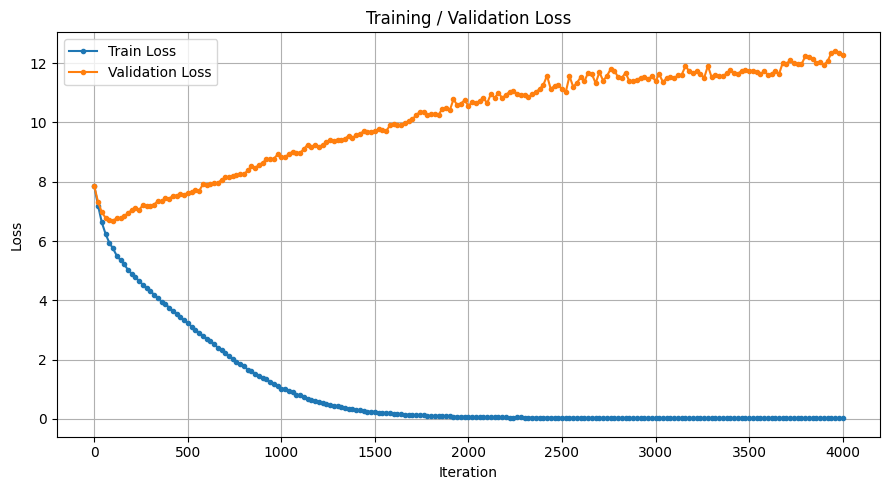

saving checkpoint to out
iter 4000: loss 0.0422, time 715.23ms, mfu 0.31%
Training finished.


In [16]:
# ============================================
# nanoGPT training + リアルタイム Loss グラフ
# 人間失格規模用
# ============================================

import subprocess
import re
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --------------------------------------------
# 学習コマンド
# --------------------------------------------
cmd = [
    "python", "-u", "train.py",
    "--dataset=jp",
    "--device=cuda",
    "--compile=False",
    "--init_from=scratch",
    "--n_layer=22",
    "--n_head=16",
    "--n_embd=128",
    "--batch_size=8",
    "--gradient_accumulation_steps=1",
    "--block_size=256",
    "--max_iters=4000",
    "--lr_decay_iters=4000",
    "--warmup_iters=20",
    "--learning_rate=4e-4",
    "--min_lr=3e-5",
    "--eval_interval=20",
    "--eval_iters=20",
    "--dropout=0.1",
    "--log_interval=10",
    "--dtype=float16"
]

# --------------------------------------------
# Loss保存用
# --------------------------------------------
steps = []
train_losses = []
val_losses = []

# nanoGPTの標準的な出力
#
# step 20: train loss 5.1234, val loss 5.2345
#
pattern = re.compile(
    r"step\s+(\d+):\s+train loss\s+([0-9.eE+-]+),\s+val loss\s+([0-9.eE+-]+)"
)

# --------------------------------------------
# train.py 起動
# --------------------------------------------
process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

# --------------------------------------------
# 出力をリアルタイム監視
# --------------------------------------------
for line in process.stdout:

    print(line, end="")

    match = pattern.search(line)

    if match:
        step = int(match.group(1))
        train_loss = float(match.group(2))
        val_loss = float(match.group(3))

        steps.append(step)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ------------------------------------
        # グラフ更新
        # ------------------------------------
        clear_output(wait=True)

        print(f"step {step}")
        print(f"train loss = {train_loss:.4f}")
        print(f"valid loss = {val_loss:.4f}")

        plt.figure(figsize=(9, 5))

        plt.plot(
            steps,
            train_losses,
            marker="o",
            markersize=3,
            label="Train Loss"
        )

        plt.plot(
            steps,
            val_losses,
            marker="o",
            markersize=3,
            label="Validation Loss"
        )

        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training / Validation Loss")

        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

process.wait()

print("Training finished.")

走れメロス規模モデル
step       = 6000 / 6000
train loss = 0.1757
valid loss = 10.2796


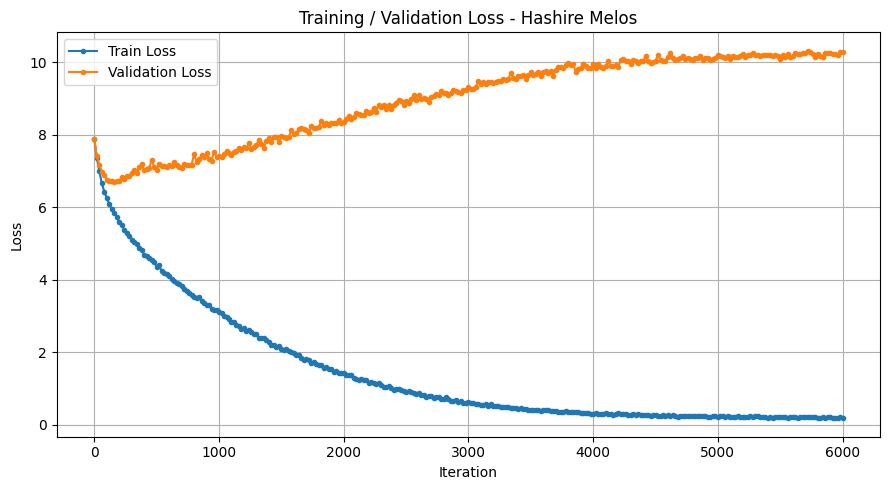

saving checkpoint to out
iter 6000: loss 0.5157, time 115.29ms, mfu 0.06%
Training finished.


In [11]:
## ============================================
# nanoGPT training + リアルタイム Loss グラフ
# 走れメロス規模用
# ============================================

import subprocess
import re
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --------------------------------------------
# 学習コマンド
# --------------------------------------------
cmd = [
    "python", "-u", "train.py",
    "--dataset=jp",
    "--device=cuda",
    "--compile=False",
    "--init_from=scratch",
    "--n_layer=2",
    "--n_head=2",
    "--n_embd=128",
    "--batch_size=4",
    "--gradient_accumulation_steps=1",
    "--block_size=128",
    "--max_iters=6000",
    "--lr_decay_iters=6000",
    "--warmup_iters=20",
    "--learning_rate=3e-4",
    "--min_lr=3e-5",
    "--eval_interval=20",
    "--eval_iters=20",
    "--dropout=0.1",
    "--log_interval=10",
    "--dtype=float16"
]

# --------------------------------------------
# Loss保存用
# --------------------------------------------
steps = []
train_losses = []
val_losses = []

# nanoGPTの出力
# step 20: train loss 5.1234, val loss 5.2345
pattern = re.compile(
    r"step\s+(\d+):\s+train loss\s+([0-9.eE+-]+),\s+val loss\s+([0-9.eE+-]+)"
)

# --------------------------------------------
# train.py 起動
# --------------------------------------------
process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

# --------------------------------------------
# 出力をリアルタイム監視
# --------------------------------------------
for line in process.stdout:

    print(line, end="")

    match = pattern.search(line)

    if match:
        step = int(match.group(1))
        train_loss = float(match.group(2))
        val_loss = float(match.group(3))

        steps.append(step)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ------------------------------------
        # グラフ更新
        # ------------------------------------
        clear_output(wait=True)

        print("走れメロス規模モデル")
        print(f"step       = {step} / 6000")
        print(f"train loss = {train_loss:.4f}")
        print(f"valid loss = {val_loss:.4f}")

        plt.figure(figsize=(9, 5))

        plt.plot(
            steps,
            train_losses,
            marker="o",
            markersize=3,
            label="Train Loss"
        )

        plt.plot(
            steps,
            val_losses,
            marker="o",
            markersize=3,
            label="Validation Loss"
        )

        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training / Validation Loss - Hashire Melos")

        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

process.wait()

print("Training finished.")

## STEP6　学習済みモデルを使って文章を生成します。

In [18]:
# generate_sp.py
import os
import re
import torch
import sentencepiece as spm
from contextlib import nullcontext

os.chdir("/content/nanoGPT")
from model import GPTConfig, GPT

# =========================
# 設定
# =========================
out_dir = "out"
sp_model_path = "/content/nanoGPT/jp.model"

prompt = "富士見西行、"
num_samples = 1
max_new_tokens = 200

device = "cuda" if torch.cuda.is_available() else "cpu"

repetition_penalty = 1.1
temperature = 0.2
top_k = 20
top_p = 0.9

# =========================
# SentencePiece
# =========================
sp = spm.SentencePieceProcessor()
sp.load(sp_model_path)

def encode(s):
    return sp.encode(s, out_type=int)

def decode(l):
    return sp.decode(l)

# =========================
# 表示整形
# 日本語・英語対応
# =========================
def format_text(text):
    # 日本語
    # 。！？ の後で改行
    # 閉じ括弧 」』）】］” が続く場合も対応
    text = re.sub(
        r'([。！？]+[」』）】］”"]*)[ \t]*',
        r'\1\n',
        text
    )

    # 英語
    # . ! ? の後に空白がある場合に改行
    # " ' などが続く場合にも対応
    text = re.sub(
        r'([.!?]+["\']?)[ \t]+',
        r'\1\n',
        text
    )

    # 行末の余分な空白を削除
    text = re.sub(r'[ \t]+\n', '\n', text)

    # 3個以上の連続改行を2個までにする
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text.strip()

# =========================
# モデル読み込み
# =========================
ckpt_path = os.path.join(out_dir, "ckpt.pt")
checkpoint = torch.load(ckpt_path, map_location=device)

model = GPT(GPTConfig(**checkpoint["model_args"]))
state_dict = checkpoint["model"]

# compile対策
for k in list(state_dict.keys()):
    if k.startswith("_orig_mod."):
        state_dict[k[len("_orig_mod."):]] = state_dict.pop(k)

model.load_state_dict(state_dict)
model.to(device)
model.eval()

ctx = nullcontext()

# =========================
# 生成
# =========================
def generate(model, idx, max_new_tokens):
    block_size = model.config.block_size
    last_tokens = []

    for _ in range(max_new_tokens):
        idx_cond = (
            idx
            if idx.size(1) <= block_size
            else idx[:, -block_size:]
        )

        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature

        # -------------------------
        # repetition penalty
        # -------------------------
        for token in set(idx[0].tolist()):
            logits[0][token] /= repetition_penalty

        # -------------------------
        # top_k
        # -------------------------
        if top_k is not None:
            k = min(top_k, logits.size(-1))
            v, _ = torch.topk(logits, k)
            logits[logits < v[:, [-1]]] = -float("Inf")

        # -------------------------
        # top_p
        # -------------------------
        if top_p is not None:
            sorted_logits, sorted_indices = torch.sort(
                logits,
                descending=True
            )

            cumulative_probs = torch.cumsum(
                torch.softmax(sorted_logits, dim=-1),
                dim=-1
            )

            sorted_indices_to_remove = cumulative_probs > top_p

            sorted_indices_to_remove[..., 1:] = (
                sorted_indices_to_remove[..., :-1].clone()
            )

            sorted_indices_to_remove[..., 0] = False

            indices_to_remove = sorted_indices[
                sorted_indices_to_remove
            ]

            logits[0][indices_to_remove] = -float("Inf")

        probs = torch.softmax(logits, dim=-1)

        # -------------------------
        # 直近tokenの反復防止
        # -------------------------
        for _ in range(10):
            next_token = torch.multinomial(
                probs,
                num_samples=1
            )

            if next_token.item() not in last_tokens:
                break

        # -------------------------
        # 履歴更新
        # -------------------------
        last_tokens.append(next_token.item())

        if len(last_tokens) > 10:
            last_tokens.pop(0)

        # -------------------------
        # token追加
        # -------------------------
        idx = torch.cat(
            (idx, next_token),
            dim=1
        )

    return idx

# =========================
# 実行
# =========================
start_ids = encode(prompt)

x = torch.tensor(
    start_ids,
    dtype=torch.long,
    device=device
)[None, ...]

with torch.no_grad():
    with ctx:
        for _ in range(num_samples):
            y = generate(
                model,
                x,
                max_new_tokens
            )

            text = decode(y[0].tolist())

            # 日本語・英語の文末で改行
            text = format_text(text)

            print("==========")
            print(text)

number of parameters: 4.66M
富士見西行、といつたところだね。
かたちが、できてる。」
私は、その僧をなつかしく思つた。
「いづれ、名のある聖僧かも知れないね。」
「ばか言ふなよ、乞食だよ。」
友人は、冷淡だつた。
「いや、いや。
脱俗してゐるところがあるよ。
歩きかたなんか、なかなか、できてるぢやないか。
むかし、能因法師が、この峠で富士をほめた歌を作つたさうだが、――」 私が言つてゐるうちに友人は、笑ひ出した。
「おい、見給へ。
できてないよ。」
能因法師は、茶店のハチといふ飼犬に吠えられて、周章狼狽であつた。
その有様は、いやになるほど、みつともなかつた。
「だめだねえ。
やつぱり。」
私は、がつかりした。
乞食の狼狽は、むしろ、あさましいほどに右往左往、つひには杖をかなぐり捨て、取り乱し、取り乱し、いまはかなはずと退散した。
実に、それは、できてなかつた。
富士も俗なら


In [ ]:
import os
import numpy as np

data_dir = "/content/nanoGPT/data/jp"

for name in ["train.bin", "val.bin"]:
    path = os.path.join(data_dir, name)
    print("\n", path)
    print("exists:", os.path.exists(path))
    if os.path.exists(path):
        print("bytes :", os.path.getsize(path))
        data = np.memmap(path, dtype=np.uint16, mode="r")
        print("tokens:", len(data))


 /content/nanoGPT/data/jp/train.bin
exists: True
bytes : 872
tokens: 436

 /content/nanoGPT/data/jp/val.bin
exists: True
bytes : 98
tokens: 49
